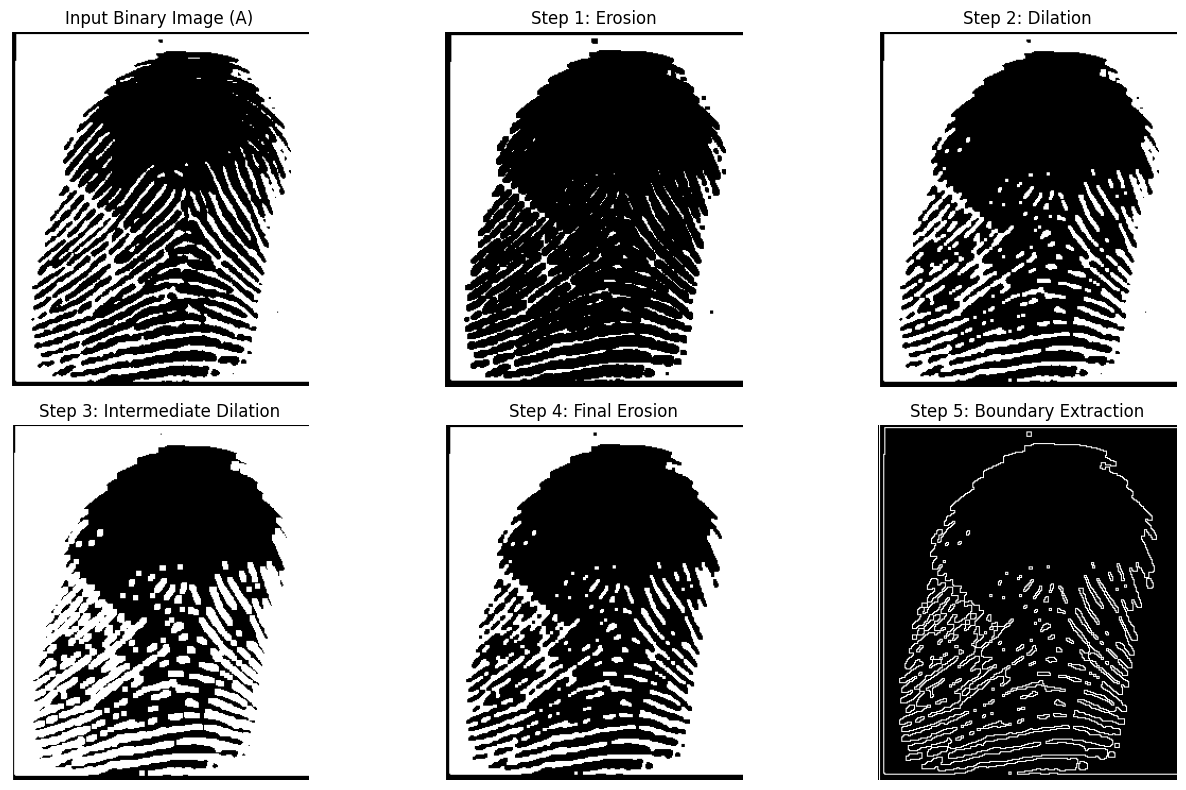

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = "pint.jpg"
A = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if A is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

_, A = cv2.threshold(A, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


B = np.ones((3, 3), dtype=np.uint8)


step1 = cv2.erode(A, B, iterations=1)


step2 = cv2.dilate(step1, B, iterations=1)

step3 = cv2.dilate(step2, B, iterations=1)


step4 = cv2.erode(step3, B, iterations=1)


boundary = cv2.subtract(step4, cv2.erode(step4, B, iterations=1))


images = [A, step1, step2, step3, step4, boundary]
titles = [
    "Input Binary Image (A)",
    "Step 1: Erosion",
    "Step 2: Dilation",
    "Step 3: Intermediate Dilation",
    "Step 4: Final Erosion",
    "Step 5: Boundary Extraction",
]

plt.figure(figsize=(14, 8))
for i, (img, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()